# Sellers EDA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [3]:
sellers = pd.read_csv("../04_Feature_Engineering/Output/sellers_features.csv")

In [7]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_city_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,"campinas, SP"
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,"mogi guacu, SP"
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,"rio de janeiro, RJ"
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,"sao paulo, SP"
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,"braganca paulista, SP"


In [4]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
 4   seller_city_state       3095 non-null   object
dtypes: int64(1), object(4)
memory usage: 121.0+ KB


In [8]:
sellers.describe(include="all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_city_state
count,3095,3095.000000,3095,3095,3095
unique,3095,NaN,611,23,636
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP,"sao paulo, SP"
freq,1,NaN,694,1849,694
mean,NaN,32291.059451,NaN,NaN,NaN
std,NaN,32713.453830,NaN,NaN,NaN
min,NaN,1001.000000,NaN,NaN,NaN
25%,NaN,7093.500000,NaN,NaN,NaN
50%,NaN,14940.000000,NaN,NaN,NaN
75%,NaN,64552.500000,NaN,NaN,NaN


In [9]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
seller_city_state         0
dtype: int64

In [10]:
sellers.duplicated().sum()

0

## 1. Seller State Analysis

In [15]:
# Counts
sellers["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
PI       1
AC       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [14]:
# Percentage
seller_state_pct = (
    sellers["seller_state"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

seller_state_pct.columns = ["seller_state", "percentage"]

seller_state_pct

,seller_state,percentage
0,SP,59.74
1,PR,11.28
2,MG,7.88
3,SC,6.14
4,RJ,5.53
5,RS,4.17
6,GO,1.29
7,DF,0.97
8,ES,0.74
9,BA,0.61


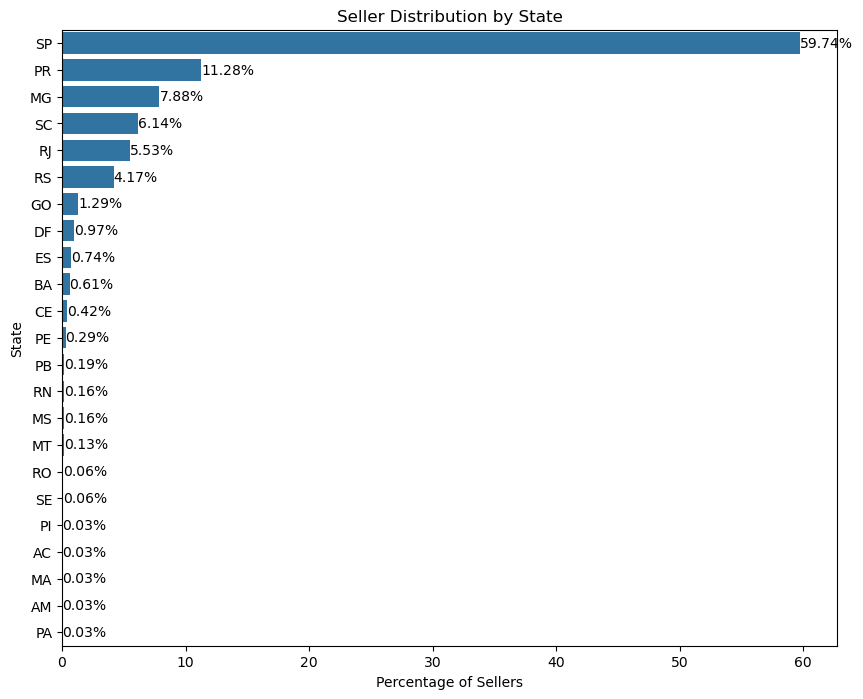

In [16]:
# Horizontal Bar Chart
plt.figure(figsize=(10,8))

ax = sns.barplot(
    data=seller_state_pct,
    x="percentage",
    y="seller_state"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Seller Distribution by State")
plt.xlabel("Percentage of Sellers")
plt.ylabel("State")

plt.show()

## 2. Seller City-State Analysis

In [18]:
# Top 20
seller_city_state = (
    sellers["seller_city_state"]
    .value_counts()
    .head(20)
    .reset_index()
)

seller_city_state.columns = ["seller_city_state", "count"]

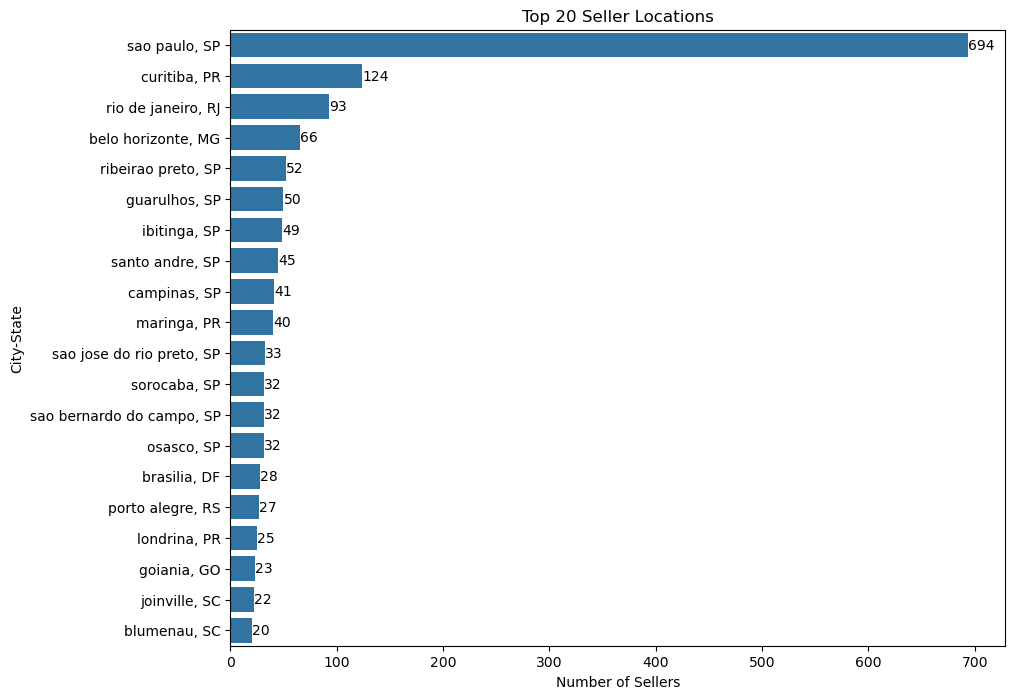

In [19]:
plt.figure(figsize=(10,8))

ax = sns.barplot(
    data=seller_city_state,
    x="count",
    y="seller_city_state"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 20 Seller Locations")
plt.xlabel("Number of Sellers")
plt.ylabel("City-State")

plt.show()

## Overall Observations

* Sellers are concentrated in a small number of states.
* Major metropolitan regions host the largest seller populations.
* The seller distribution is more geographically concentrated than smaller regions.

## Business Insights

* High seller concentration can improve delivery efficiency in major regions.
* Regions with fewer sellers may present opportunities to expand the seller network.
* Geographic seller distribution should be considered when evaluating delivery performance and marketplace coverage.